# 02 · Feature Engineering

Build the sparse interaction matrix, user feature vectors, and item feature vectors used by all downstream models.

In [1]:
import sys
sys.path.insert(0, '..')

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz

from config import SPLITS_DIR, PROCESSED_DIR, REPORTS_DIR
from src.data.load_data import get_data
from src.data.preprocess import run_pipeline
from src.features.build_features import run_feature_pipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1 · Run Preprocessing Pipeline

In [2]:
train_raw, val_raw = get_data()
data = run_pipeline(train_raw, val_raw)

train    = data['train']
val      = data['val']
test     = data['test']
n_users  = data['n_users']
n_movies = data['n_movies']

print(f'\nTrain : {len(train):,} rows')
print(f'Val   : {len(val):,} rows')
print(f'Test  : {len(test):,} rows')
print(f'Users : {n_users:,}')
print(f'Movies: {n_movies:,}')

Loading from local cache...
After cleaning : 940,090 rows | 29,474 users | 7,642 movies
Encoded        : 29,474 users | 7,642 movies
Split          : train 688,779 | val 73,940 | test 177,371
Saved splits   → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\data\splits
Saved mappings → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\data\processed

Train : 688,779 rows
Val   : 73,940 rows
Test  : 177,371 rows
Users : 29,474
Movies: 7,642


## 2 · Build Feature Matrices

In [3]:
# Re-parse genre_list from string if needed (parquet round-trip)
for df in (train, val, test):
    if 'genre_list' in df.columns and isinstance(df['genre_list'].iloc[0], str):
        df['genre_list'] = df['genre_list'].apply(ast.literal_eval)

features = run_feature_pipeline(train, n_users, n_movies)

user_features   = features['user_features']
item_features   = features['item_features']
interaction_mat = features['interaction_mat']

User features  : 29,474 users × 25 features


c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1016: UserWarning: unknown class(es) ['(no genres listed)'] will be ignored
  warnings.warn(


Item features  : 7,641 movies × 26 features
Interaction matrix : (29474, 7642) | sparsity 99.6942%
Saved features → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\data\processed


## 3 · Interaction Matrix Analysis

Matrix shape    : (29474, 7642)
Non-zero entries: 688,779
Density         : 0.3058%
Sparsity        : 99.6942%


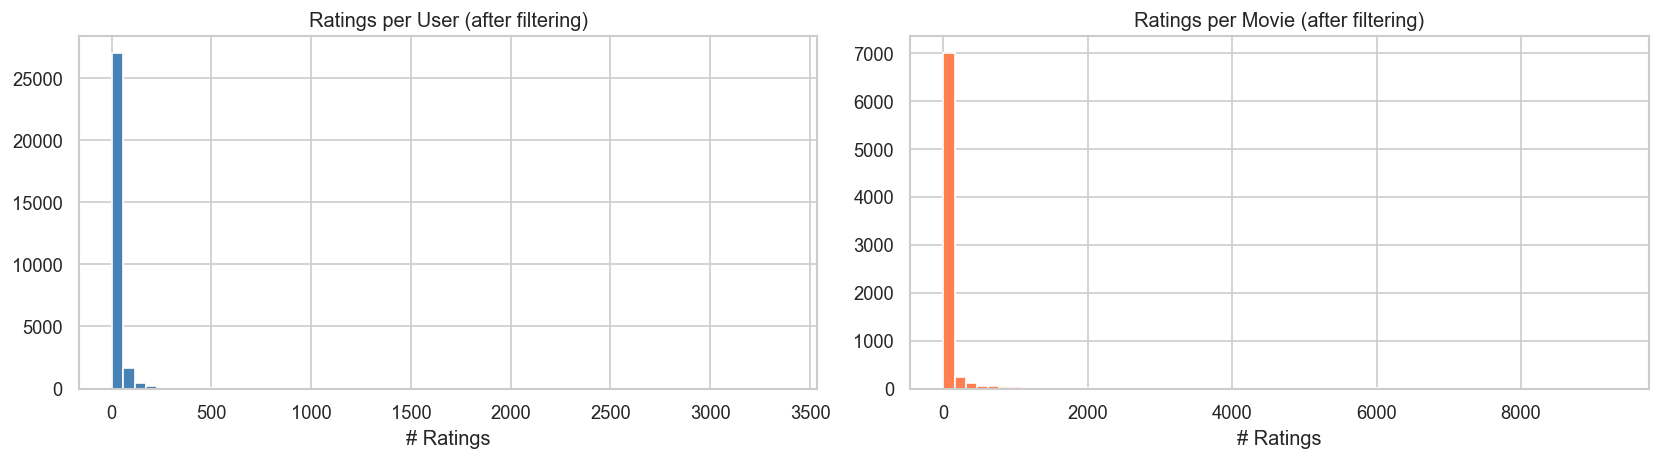

In [4]:
mat = interaction_mat
print(f'Matrix shape    : {mat.shape}')
print(f'Non-zero entries: {mat.nnz:,}')
print(f'Density         : {mat.nnz / (mat.shape[0] * mat.shape[1]):.4%}')
print(f'Sparsity        : {1 - mat.nnz / (mat.shape[0] * mat.shape[1]):.4%}')

# Ratings per user (non-zero rows)
user_nnz  = np.diff(mat.tocsr().indptr)
movie_nnz = np.diff(mat.tocsc().indptr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(user_nnz[user_nnz > 0], bins=60, color='steelblue')
axes[0].set_title('Ratings per User (after filtering)')
axes[0].set_xlabel('# Ratings')

axes[1].hist(movie_nnz[movie_nnz > 0], bins=60, color='coral')
axes[1].set_title('Ratings per Movie (after filtering)')
axes[1].set_xlabel('# Ratings')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'filtered_matrix_stats.png')
plt.show()

## 4 · User Feature Inspection

In [5]:
print(f'User feature matrix: {user_features.shape}')
print('\nFeature columns:')
print(user_features.columns.tolist())
user_features.describe().round(3)

User feature matrix: (29474, 25)

Feature columns:
['user_idx', 'mean_rating', 'rating_std', 'n_ratings', 'log_n_ratings', 'genre_affinity_action', 'genre_affinity_adventure', 'genre_affinity_animation', 'genre_affinity_children', 'genre_affinity_comedy', 'genre_affinity_crime', 'genre_affinity_documentary', 'genre_affinity_drama', 'genre_affinity_fantasy', 'genre_affinity_film_noir', 'genre_affinity_horror', 'genre_affinity_imax', 'genre_affinity_musical', 'genre_affinity_mystery', 'genre_affinity_romance', 'genre_affinity_sci_fi', 'genre_affinity_thriller', 'genre_affinity_war', 'genre_affinity_western', 'genre_affinity_unknown']


,user_idx,mean_rating,rating_std,n_ratings,log_n_ratings,genre_affinity_action,genre_affinity_adventure,genre_affinity_animation,genre_affinity_children,genre_affinity_comedy,...,genre_affinity_horror,genre_affinity_imax,genre_affinity_musical,genre_affinity_mystery,genre_affinity_romance,genre_affinity_sci_fi,genre_affinity_thriller,genre_affinity_war,genre_affinity_western,genre_affinity_unknown
count,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,...,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.000,29474.0
mean,14736.500,3.455,0.708,23.369,2.654,3.024,3.043,2.297,1.870,3.062,...,1.227,1.125,0.697,1.385,1.990,2.934,2.862,1.729,0.703,0.0
std,8508.555,0.714,0.375,43.292,0.932,1.295,1.333,1.784,1.828,1.299,...,1.654,1.669,1.399,1.739,1.787,1.417,1.500,1.866,1.425,0.0
min,0.000,0.500,0.000,3.000,1.386,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
25%,7368.250,3.071,0.452,6.000,1.946,2.650,2.675,0.000,0.000,2.711,...,0.000,0.000,0.000,0.000,0.000,2.500,2.500,0.000,0.000,0.0
50%,14736.500,3.500,0.640,11.000,2.485,3.350,3.417,3.000,2.000,3.400,...,0.000,0.000,0.000,0.000,2.500,3.333,3.333,0.000,0.000,0.0
75%,22104.750,3.919,0.904,24.000,3.219,3.891,4.000,3.833,3.500,4.000,...,3.000,3.000,0.000,3.250,3.500,4.000,4.000,3.500,0.000,0.0
max,29473.000,5.000,2.598,3369.000,8.123,5.000,5.000,5.000,5.000,5.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,0.0


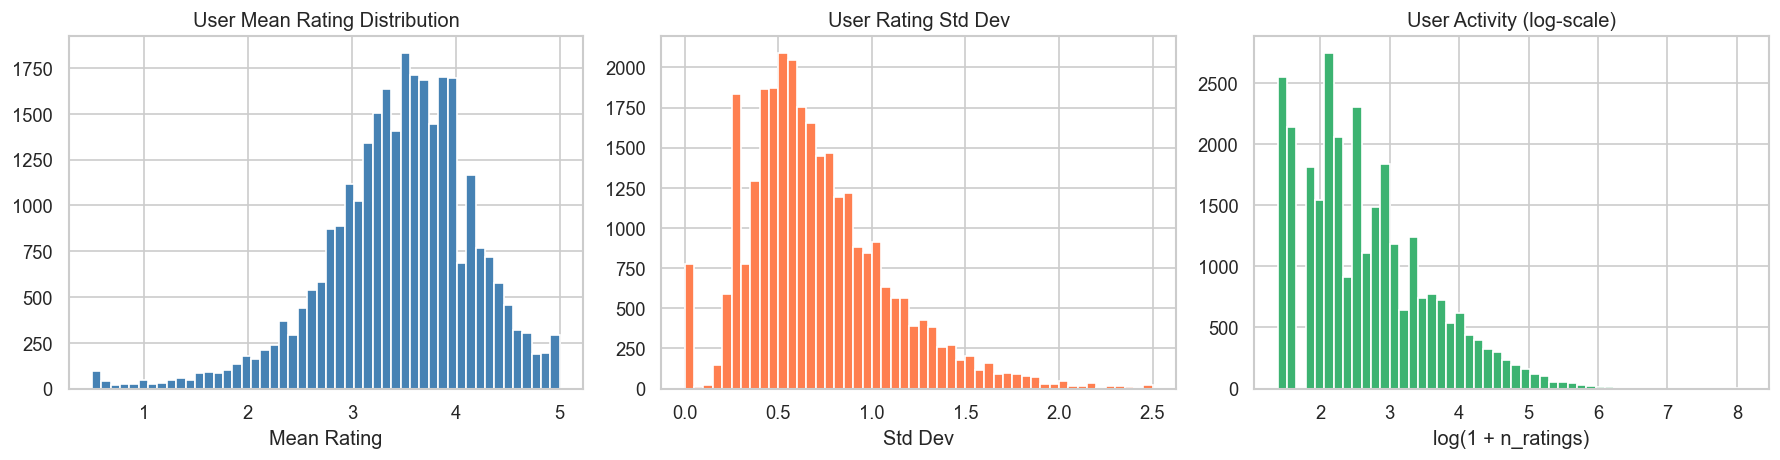

In [6]:
# Distribution of mean ratings
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(user_features['mean_rating'], bins=50, color='steelblue')
axes[0].set_title('User Mean Rating Distribution')
axes[0].set_xlabel('Mean Rating')

axes[1].hist(user_features['rating_std'].clip(upper=2.5), bins=50, color='coral')
axes[1].set_title('User Rating Std Dev')
axes[1].set_xlabel('Std Dev')

axes[2].hist(user_features['log_n_ratings'], bins=50, color='mediumseagreen')
axes[2].set_title('User Activity (log-scale)')
axes[2].set_xlabel('log(1 + n_ratings)')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'user_feature_distributions.png')
plt.show()

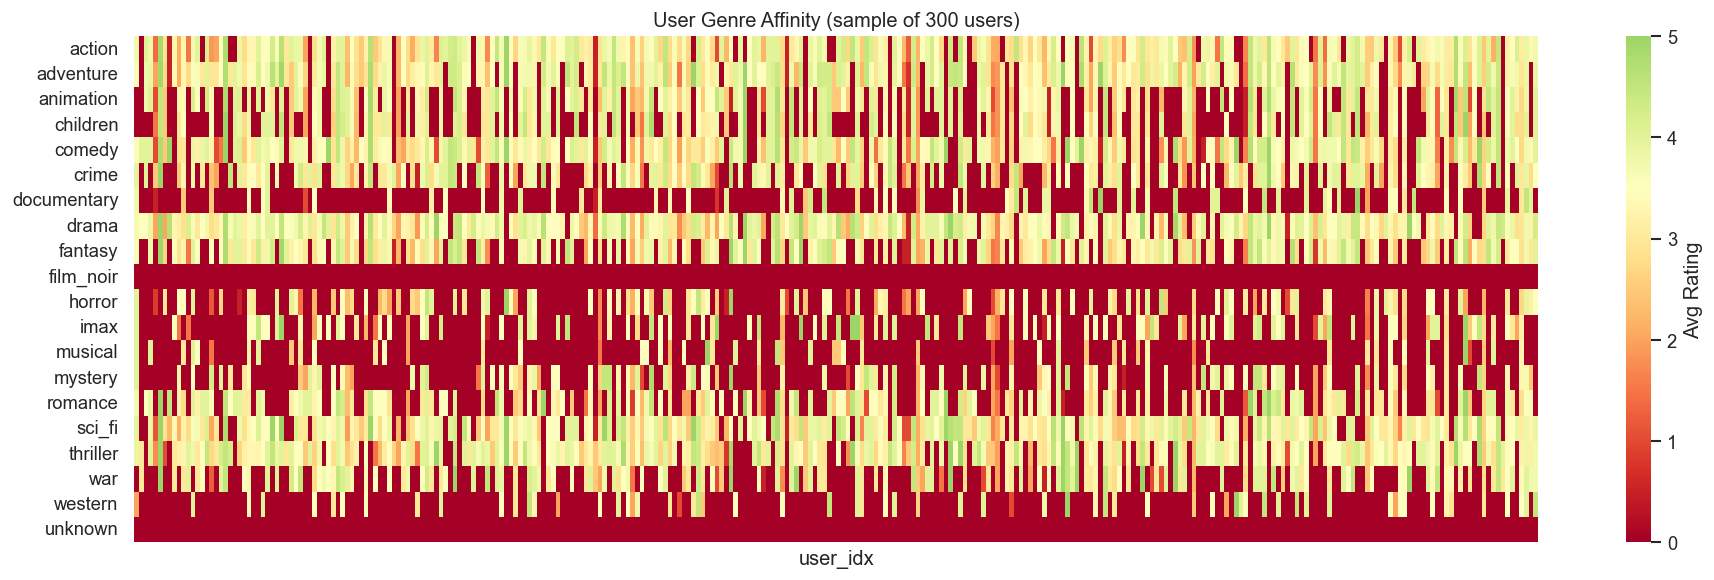

In [7]:
# Genre affinity heatmap (sample users)
genre_cols = [c for c in user_features.columns if c.startswith('genre_affinity_')]
sample_uf  = user_features.sample(300, random_state=42).set_index('user_idx')[genre_cols]
sample_uf.columns = [c.replace('genre_affinity_', '') for c in sample_uf.columns]

plt.figure(figsize=(16, 5))
sns.heatmap(sample_uf.T, cmap='RdYlGn', center=3.5, linewidths=0,
            xticklabels=False, cbar_kws={'label': 'Avg Rating'})
plt.title('User Genre Affinity (sample of 300 users)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'user_genre_affinity.png')
plt.show()

## 5 · Item Feature Inspection

In [8]:
print(f'Item feature matrix: {item_features.shape}')
item_features.describe().round(3)

Item feature matrix: (7641, 26)


,movie_idx,mean_rating,rating_std,n_ratings,log_n_ratings,year,genre_action,genre_adventure,genre_animation,genre_children,...,genre_horror,genre_imax,genre_musical,genre_mystery,genre_romance,genre_sci_fi,genre_thriller,genre_war,genre_western,genre_unknown
count,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,...,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.000,7641.0
mean,3820.635,2.863,0.970,90.143,2.887,1992.714,0.124,0.057,0.066,0.046,...,0.114,0.001,0.004,0.044,0.090,0.071,0.172,0.017,0.006,0.0
std,2206.313,0.533,0.336,425.395,1.348,211.434,0.330,0.231,0.248,0.209,...,0.318,0.038,0.065,0.206,0.287,0.257,0.377,0.131,0.077,0.0
min,0.000,0.500,0.000,1.000,0.693,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
25%,1910.000,2.583,0.774,6.000,1.946,2014.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
50%,3821.000,2.940,0.957,11.000,2.485,2015.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
75%,5731.000,3.250,1.157,30.000,3.434,2017.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
max,7641.000,4.500,2.828,9304.000,9.138,2019.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0


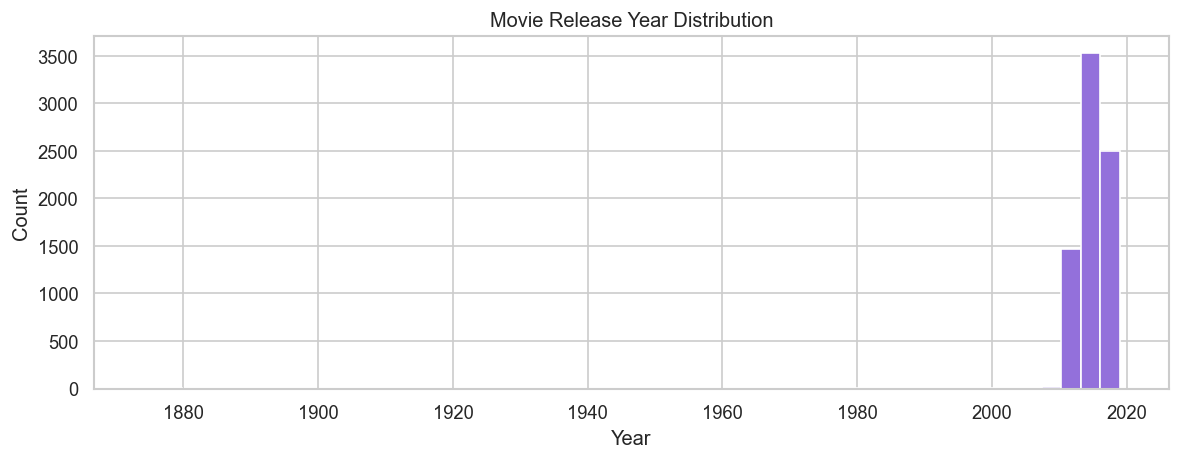

In [9]:
# Year distribution
if 'year' in item_features.columns:
    years = item_features['year'].replace(0, np.nan).dropna()
    plt.figure(figsize=(10, 4))
    plt.hist(years, bins=50, color='mediumpurple')
    plt.title('Movie Release Year Distribution')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'movie_years.png')
    plt.show()

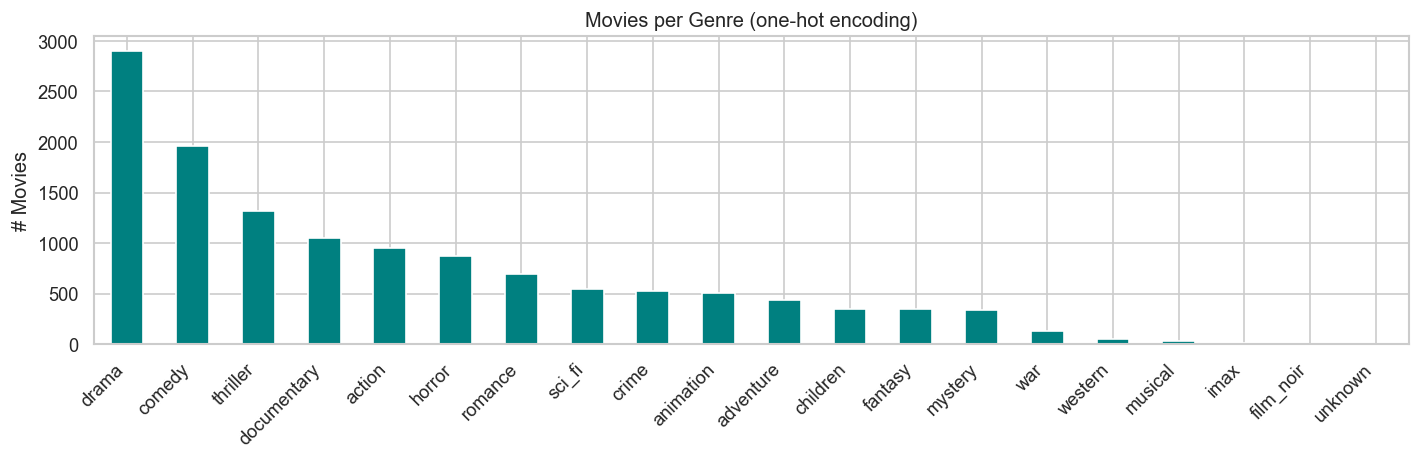

In [10]:
# Genre one-hot coverage
genre_ohe_cols = [c for c in item_features.columns if c.startswith('genre_') and c != 'genre_list']
genre_coverage = item_features[genre_ohe_cols].sum().sort_values(ascending=False)
genre_coverage.index = [c.replace('genre_', '') for c in genre_coverage.index]

plt.figure(figsize=(12, 4))
genre_coverage.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Movies per Genre (one-hot encoding)')
plt.ylabel('# Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'genre_onehot.png')
plt.show()

## 6 · Feature Correlation

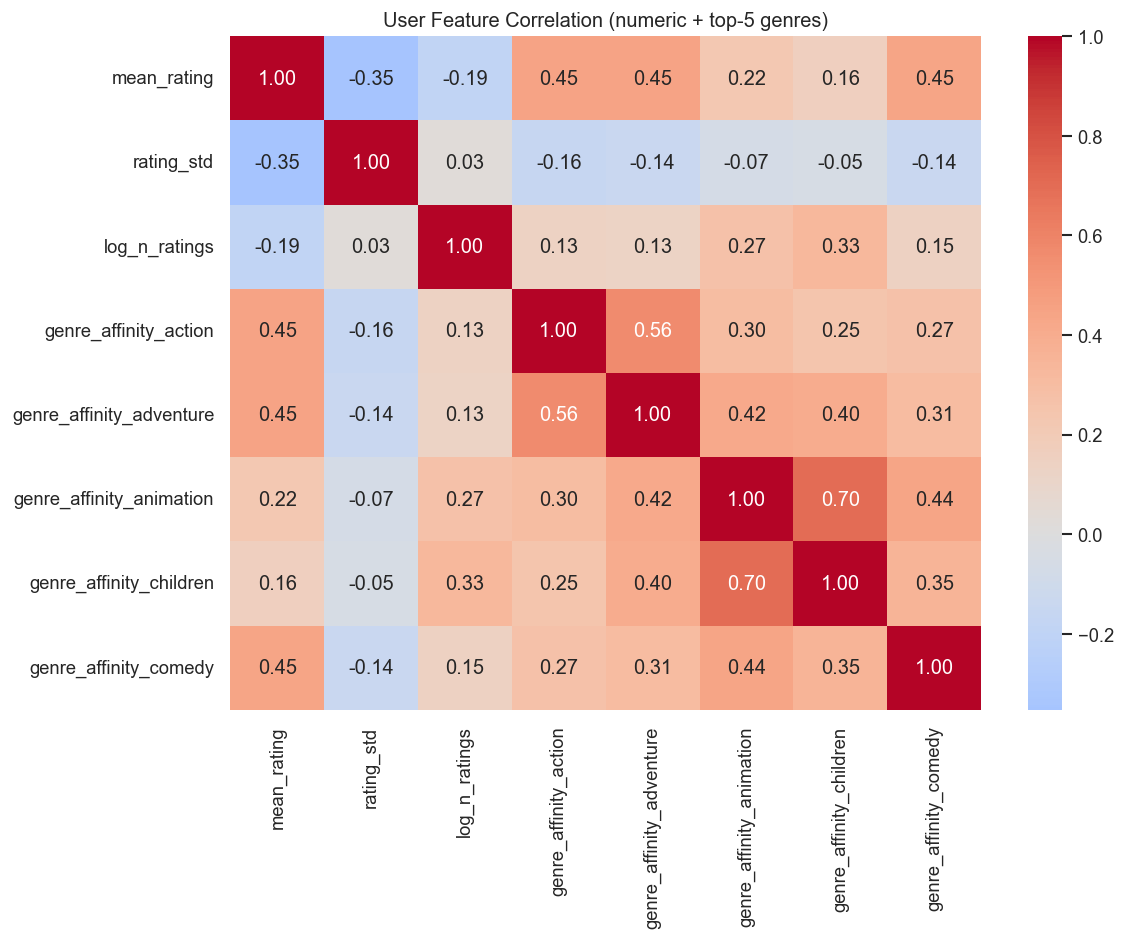

In [11]:
num_user_cols = ['mean_rating', 'rating_std', 'log_n_ratings']
corr = user_features[num_user_cols + genre_cols[:5]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('User Feature Correlation (numeric + top-5 genres)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'user_feature_corr.png')
plt.show()

## 7 · Summary

In [12]:
print('=== Feature Engineering Summary ===')
print(f'Interaction matrix : {interaction_mat.shape}, sparsity {1 - interaction_mat.nnz/(interaction_mat.shape[0]*interaction_mat.shape[1]):.4%}')
print(f'User features      : {user_features.shape[0]} users × {user_features.shape[1]} features')
print(f'Item features      : {item_features.shape[0]} movies × {item_features.shape[1]} features')
print()
print('Key user features  : mean_rating, rating_std, log_n_ratings, genre_affinity_* (20)')
print('Key item features  : mean_rating, rating_std, log_n_ratings, year, genre_* (20)')
print()
print('All features saved to:', PROCESSED_DIR)

=== Feature Engineering Summary ===
Interaction matrix : (29474, 7642), sparsity 99.6942%
User features      : 29474 users × 25 features
Item features      : 7641 movies × 26 features

Key user features  : mean_rating, rating_std, log_n_ratings, genre_affinity_* (20)
Key item features  : mean_rating, rating_std, log_n_ratings, year, genre_* (20)

All features saved to: c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\data\processed
